# Dataset upload

In [1]:
import pandas as pd

#loading dataset
dataset = pd.read_csv('/Users/rohan/Desktop/rohan/HWU/Masters project and dissertation/dataset/dataset1.csv')

#'label' column to 'sentiment'
dataset.rename(columns={'label': 'sentiment'}, inplace=True)

dataset = dataset[['message', 'sentiment']]

#modified dataset
print(dataset.head())

                                             message  sentiment
0  just had a real good moment. i missssssssss hi...          0
1         is reading manga  http://plurk.com/p/mzp1e          0
2  @comeagainjen http://twitpic.com/2y2lx - http:...          0
3  @lapcat Need to send 'em to my accountant tomo...          0
4      ADD ME ON MYSPACE!!!  myspace.com/LookThunder          0


In [2]:
pip install textblob

Note: you may need to restart the kernel to use updated packages.


# Data Pre-Processing

In [3]:
from textblob import TextBlob

# Function for sentiment polarity
def get_sentiment(text):
    analysis = TextBlob(text)
    
    # Returning sentiment polarity as positive, negative, or neutral
    if analysis.sentiment.polarity > 0:
        return 'positive'
    elif analysis.sentiment.polarity < 0:
        return 'negative'
    else:
        return 'neutral'

# Applying sentiment analysis to each message in the dataset
dataset['sentiment'] = dataset['message'].apply(get_sentiment)

# modified dataset display 
print(dataset.head())


/Users/rohan/Desktop/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


                                             message sentiment
0  just had a real good moment. i missssssssss hi...  positive
1         is reading manga  http://plurk.com/p/mzp1e   neutral
2  @comeagainjen http://twitpic.com/2y2lx - http:...   neutral
3  @lapcat Need to send 'em to my accountant tomo...  positive
4      ADD ME ON MYSPACE!!!  myspace.com/LookThunder   neutral


In [4]:
import re
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

# Initializing WordNet Lemmatizer
lemmatizer = WordNetLemmatizer()

# Set of English stopwords
stopWordsSet = set(stopwords.words('english'))
#cleaning data
def preprocess_text(text):
    # Remove URLs
    text = re.sub(r'http[s]?://\S+|www\.\S+', '', text)
    # Remove usernames (with '@')
    text = re.sub(r'@\w+', '', text)
    # Remove non-alphanumeric characters
    text = re.sub(r'[^\w\s]', '', text)
    # Remove single characters
    text = re.sub(r'\s+[a-zA-Z]\s+', ' ', text)
    # Remove extra whitespaces
    text = re.sub(r'\s\s+', ' ', text)
    # Convert to lowercase
    text = text.lower()
    # Tokenization 
    tokens = text.split()
    # Lemmatization
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    # Remove stopwords
    tokens = [token for token in tokens if token not in stopWordsSet]
    # Join tokens back into a string
    preprocessed_text = ' '.join(tokens)
    return preprocessed_text

# Removing rows with NaN values in the 'message' column
dataset.dropna(subset=['message'], inplace=True)

# preprocessed to the 'message' column
dataset['preprocessed_message'] = dataset['message'].apply(preprocess_text)

# Displaying eg. of preprocessed messages for each sentiment category
print("Examples of preprocessed messages for each sentiment category:")
for sentiment_label in dataset['sentiment'].unique():
    print(f"\nSentiment: {sentiment_label}")
    sentiment_examples = dataset[dataset['sentiment'] == sentiment_label].head(3)
    for idx, example in enumerate(sentiment_examples.iterrows(), start=1):
        print(f"Example {idx}: Sentiment: {example[1]['sentiment']}, Message: {example[1]['preprocessed_message']}")


Examples of preprocessed messages for each sentiment category:

Sentiment: positive
Example 1: Sentiment: positive, Message: real good moment miss much
Example 2: Sentiment: positive, Message: need send em accountant tomorrow oddly wasnt even referring tax supporting evidence though
Example 3: Sentiment: positive, Message: sleepy good time tonight though

Sentiment: neutral
Example 1: Sentiment: neutral, Message: reading manga
Example 2: Sentiment: neutral, Message: 
Example 3: Sentiment: neutral, Message: add myspace myspacecomlookthunder

Sentiment: negative
Example 1: Sentiment: negative, Message: nbn someone already said doe fiber home mean least regular
Example 2: Sentiment: negative, Message: probs sell nothing blog ill get listen band itunes
Example 3: Sentiment: negative, Message: havent able sleep think ill watch ugly betty online


In [5]:
# #cleaned dataset for LLMs further
# file_path = "/Users/rohan/Desktop/rohan/HWU/Masters project and dissertation/dataset/clndataset1.csv" 
# dataset.to_csv(file_path, index=False)

# Data Analysis

In [6]:
import re
def preprocess_text(text):
    text = re.sub(r'http[s]?://\S+|www\.\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+[a-zA-Z]\s+', ' ', text)
    text = re.sub(r'\s\s+', ' ', text)
    text = text.lower()   
    return text

def preprocess_and_filter(text, sentiment):
  
    preprocessed_text = preprocess_text(text)
    # Check if the sentiment is positive
    if sentiment == 'positive':
        if 'depression' in preprocessed_text:
            negative_patterns = ['not feeling good', 'feeling down']
            if any(re.search(pattern, preprocessed_text) for pattern in negative_patterns):
                sentiment = 'neutral'  
    
    return preprocessed_text, sentiment

In [7]:
from collections import Counter
import matplotlib.pyplot as plt

def get_word_frequency(text_list):
    # Combining all preprocessed text into a single string
    combined_text = ' '.join(text_list)
    
    # Tokenizing the combined text
    tokens = combined_text.split()
    
    # Counting the frequency of each word
    word_freq = Counter(tokens)
    
    return word_freq
#wordfrequency plotting
def plot_word_frequency(word_freq, title):
    plt.figure(figsize=(10, 6))
    plt.bar(*zip(*word_freq.most_common(20)))
    plt.title(title)
    plt.xlabel('Words')
    plt.ylabel('Frequency')
    plt.xticks(rotation=45, ha='right')
    plt.show()

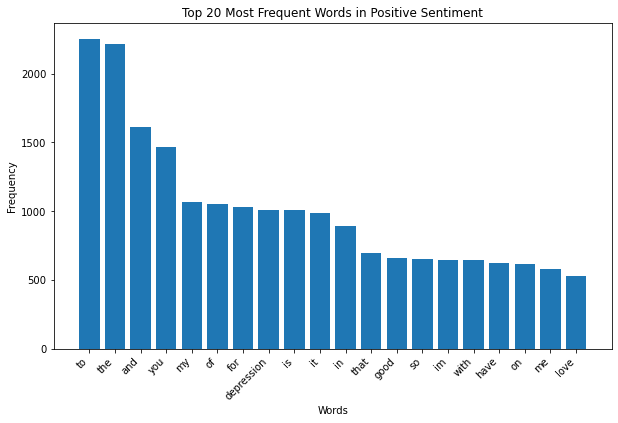

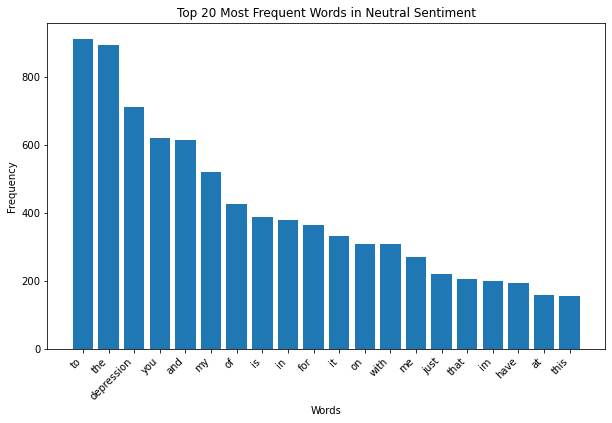

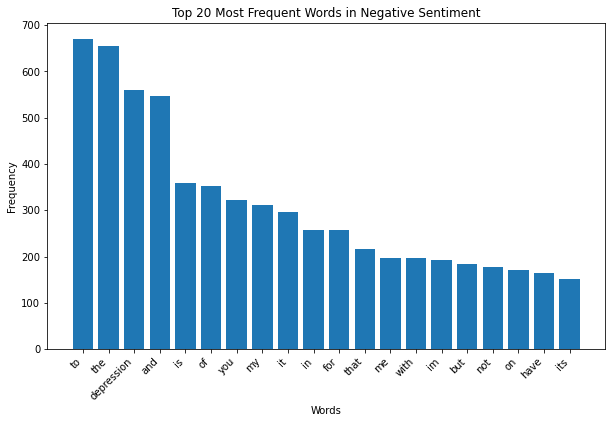

In [8]:
# Applying preprocessing and filtering the dataset
dataset['preprocessed_message'], dataset['sentiment'] = zip(*dataset.apply(lambda row: preprocess_and_filter(row['message'], row['sentiment']), axis=1))

# Getting word frequency for each sentiment category
word_freq_positive = get_word_frequency(dataset[dataset['sentiment'] == 'positive']['preprocessed_message'])
word_freq_negative = get_word_frequency(dataset[dataset['sentiment'] == 'negative']['preprocessed_message'])
word_freq_neutral = get_word_frequency(dataset[dataset['sentiment'] == 'neutral']['preprocessed_message'])

#word frequency for positive sentiment
plot_word_frequency(word_freq_positive, 'Top 20 Most Frequent Words in Positive Sentiment')
#neutral sentiment
plot_word_frequency(word_freq_neutral, 'Top 20 Most Frequent Words in Neutral Sentiment')
#negative sentiment
plot_word_frequency(word_freq_negative, 'Top 20 Most Frequent Words in Negative Sentiment')

## Training/Testing dataset

In [9]:
total_data_entries = dataset.shape[0]
print("Total data entries in the dataset:", total_data_entries)

Total data entries in the dataset: 10314


In [10]:
from sklearn.model_selection import train_test_split

# Splitting the dataset, features (X) and target variable (y)
X = dataset['preprocessed_message']
y = dataset['sentiment']

# Splitting the dataset into training-testing sets (80%, 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Displaying the shapes of datasets
print("Training dataset shape (X, y):", X_train.shape, y_train.shape)
print("Testing dataset shape (X, y):", X_test.shape, y_test.shape)


Training dataset shape (X, y): (8251,) (8251,)
Testing dataset shape (X, y): (2063,) (2063,)


In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Initializing the TF-IDF
tfidf_vectorizer = TfidfVectorizer()

# Fitting and transforming the training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)

# Transforming the testing data
X_test_tfidf = tfidf_vectorizer.transform(X_test)

# shapes of the transformed datasets
print("Training dataset shape after TF-IDF vectorization:", X_train_tfidf.shape)
print("Testing dataset shape after TF-IDF vectorization:", X_test_tfidf.shape)


Training dataset shape after TF-IDF vectorization: (8251, 15064)
Testing dataset shape after TF-IDF vectorization: (2063, 15064)


# ML algorithms/ Models

## Logistic Regression

Training Logistic Regression...


/Users/rohan/Desktop/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Training completed.
Logistic Regression predictions completed.


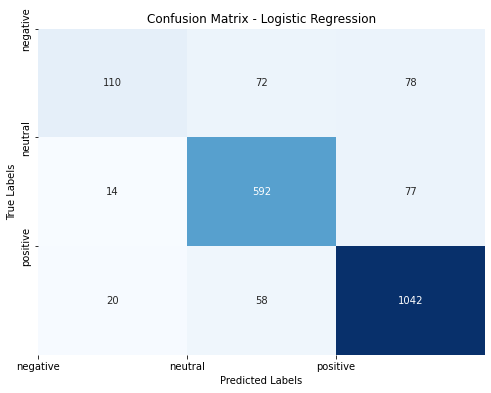

Logistic Regression Classification Report:
              precision    recall  f1-score   support

    negative       0.76      0.42      0.54       260
     neutral       0.82      0.87      0.84       683
    positive       0.87      0.93      0.90      1120

    accuracy                           0.85      2063
   macro avg       0.82      0.74      0.76      2063
weighted avg       0.84      0.85      0.84      2063

Logistic Regression Accuracy: 0.8453708191953466
Logistic Regression evaluation done.


In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Initializing Logistic Regression model
model_lr = LogisticRegression(C=2, max_iter=1000, n_jobs=-1)

# Training Logistic Regression model
print("Training Logistic Regression...")
model_lr.fit(X_train_tfidf, y_train)
print("Training completed.")

# Predictions for Logistic Regression
output_predicted_lr = model_lr.predict(X_test_tfidf)
print("Logistic Regression predictions completed.")

# Defining sentiment labels
sentiment_labels = ['negative', 'neutral', 'positive']

# Computing confusion matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, output_predicted_lr)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues", cbar=False)

#labels for x-axis and y-axis
plt.xticks(np.arange(len(sentiment_labels)), sentiment_labels)
plt.yticks(np.arange(len(sentiment_labels)), sentiment_labels)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Evaluation of Logistic Regression
print("Logistic Regression Classification Report:")
print(classification_report(y_test, output_predicted_lr))
print("Logistic Regression Accuracy:", accuracy_score(y_test, output_predicted_lr))
print("Logistic Regression evaluation done.")


## SVM 

Training Support Vector Machine...
Training completed.
Support Vector Machine predictions completed.


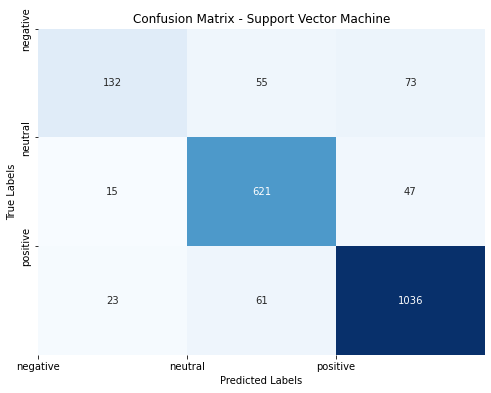

Support Vector Machine Classification Report:
              precision    recall  f1-score   support

    negative       0.78      0.51      0.61       260
     neutral       0.84      0.91      0.87       683
    positive       0.90      0.93      0.91      1120

    accuracy                           0.87      2063
   macro avg       0.84      0.78      0.80      2063
weighted avg       0.86      0.87      0.86      2063

Support Vector Machine Accuracy: 0.8671837130392632
Support Vector Machine evaluation done.


In [13]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Initializing Support Vector Machine classifier
model_svm = SVC(kernel='linear')

# Training Support Vector Machine classifier
print("Training Support Vector Machine...")
model_svm.fit(X_train_tfidf, y_train)
print("Training completed.")

# Predictions for Support Vector Machine classifier
output_predicted_svm = model_svm.predict(X_test_tfidf)
print("Support Vector Machine predictions completed.")

#sentiment labels defined
sentiment_labels = ['negative', 'neutral', 'positive']

# Computing confusion matrix for Support Vector Machine classifier
cm_svm = confusion_matrix(y_test, output_predicted_svm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Blues", cbar=False)

#labels for x-axis and y-axis
plt.xticks(np.arange(len(sentiment_labels)), sentiment_labels)
plt.yticks(np.arange(len(sentiment_labels)), sentiment_labels)

plt.title("Confusion Matrix - Support Vector Machine")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Evaluation of Support Vector Machine classifier
print("Support Vector Machine Classification Report:")
print(classification_report(y_test, output_predicted_svm))
print("Support Vector Machine Accuracy:", accuracy_score(y_test, output_predicted_svm))
print("Support Vector Machine evaluation done.")


## Decision Tree

Training Decision Tree...
Training completed.
Decision Tree predictions completed.


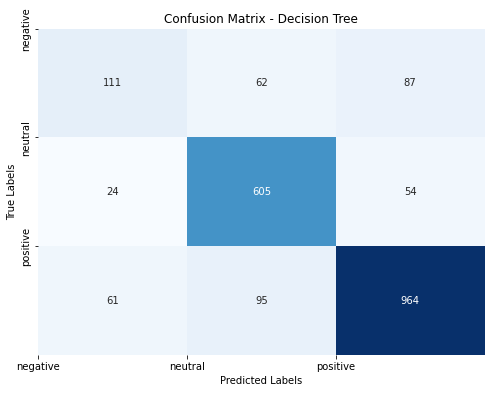

Decision Tree Classification Report:
              precision    recall  f1-score   support

    negative       0.57      0.43      0.49       260
     neutral       0.79      0.89      0.84       683
    positive       0.87      0.86      0.87      1120

    accuracy                           0.81      2063
   macro avg       0.74      0.72      0.73      2063
weighted avg       0.81      0.81      0.81      2063

Decision Tree Accuracy: 0.814348036839554
Decision Tree evaluation done.


In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Initializing Decision Tree classifier
model_dt = DecisionTreeClassifier()

# Training Decision Tree classifier
print("Training Decision Tree...")
model_dt.fit(X_train_tfidf, y_train)
print("Training completed.")

# Predictions for Decision Tree classifier
output_predicted_dt = model_dt.predict(X_test_tfidf)
print("Decision Tree predictions completed.")

# Define sentiment labels
sentiment_labels = ['negative', 'neutral', 'positive']

# Compute confusion matrix for Decision Tree classifier
cm_dt = confusion_matrix(y_test, output_predicted_dt
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues", cbar=False)

#labels for x-axis and y-axis
plt.xticks(np.arange(len(sentiment_labels)), sentiment_labels)
plt.yticks(np.arange(len(sentiment_labels)), sentiment_labels)

plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Evaluating Decision Tree classifier
print("Decision Tree Classification Report:")
print(classification_report(y_test, output_predicted_dt))
print("Decision Tree Accuracy:", accuracy_score(y_test, output_predicted_dt))
print("Decision Tree evaluation done.")


## Naive Bayes

Training Multinomial Naive Bayes...
Training completed.
Multinomial Naive Bayes predictions completed.


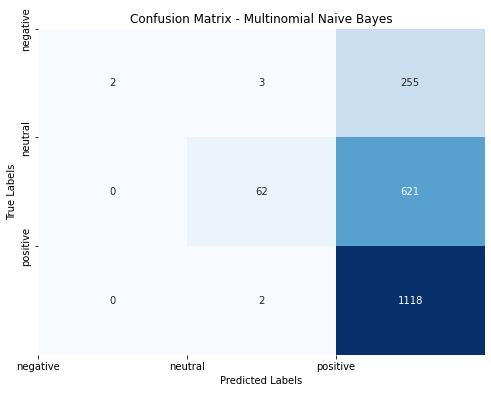

Multinomial Naive Bayes Classification Report:
              precision    recall  f1-score   support

    negative       1.00      0.01      0.02       260
     neutral       0.93      0.09      0.17       683
    positive       0.56      1.00      0.72      1120

    accuracy                           0.57      2063
   macro avg       0.83      0.37      0.30      2063
weighted avg       0.74      0.57      0.45      2063

Naive Bayes Accuracy: 0.5729520116335434
Naive Bayes evaluation done.


In [15]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Initializing Multinomial Naive Bayes model
model_nb = MultinomialNB()

# Training Multinomial Naive Bayes model
print("Training Multinomial Naive Bayes...")
model_nb.fit(X_train_tfidf, y_train)
print("Training completed.")

# Predictions for Multinomial Naive Bayes
output_predicted_nb = model_nb.predict(X_test_tfidf)
print("Multinomial Naive Bayes predictions completed.")

# Defining sentiment labels
sentiment_labels = ['negative', 'neutral', 'positive']

# confusion matrix for Multinomial Naive Bayes
cm_nb = confusion_matrix(y_test, output_predicted_nb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="Blues", cbar=False)

# Setting labels 
plt.xticks(np.arange(len(sentiment_labels)), sentiment_labels)
plt.yticks(np.arange(len(sentiment_labels)), sentiment_labels)

plt.title("Confusion Matrix - Multinomial Naive Bayes")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Evaluation of Multinomial Naive Bayes
print("Multinomial Naive Bayes Classification Report:")
print(classification_report(y_test, output_predicted_nb))
print("Naive Bayes Accuracy:", accuracy_score(y_test, output_predicted_nb))
print("Naive Bayes evaluation done.")


## KNN Model

Training KNN...
Training completed.
KNN predictions completed.


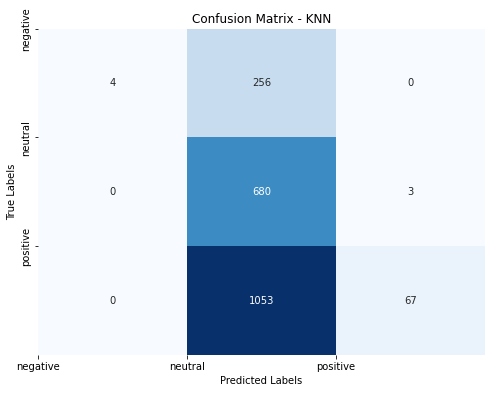

KNN Classification Report:
              precision    recall  f1-score   support

    negative       1.00      0.02      0.03       260
     neutral       0.34      1.00      0.51       683
    positive       0.96      0.06      0.11      1120

    accuracy                           0.36      2063
   macro avg       0.77      0.36      0.22      2063
weighted avg       0.76      0.36      0.23      2063

KNN Accuracy: 0.36403296170625304
KNN evaluation done.


In [16]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Initializing KNN model
model_knn = KNeighborsClassifier(n_neighbors=5)  

# Training KNN model
print("Training KNN...")
model_knn.fit(X_train_tfidf, y_train)
print("Training completed.")

# Predictions
output_predicted_knn = model_knn.predict(X_test_tfidf)
print("KNN predictions completed.")

# Defining sentiment labels
sentiment_labels = ['negative', 'neutral', 'positive']

# Compute confusion matrix for KNN
cm_knn = confusion_matrix(y_test, output_predicted_knn)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="Blues", cbar=False)

# Setting labels for x-axis and y-axis
plt.xticks(np.arange(len(sentiment_labels)), sentiment_labels)
plt.yticks(np.arange(len(sentiment_labels)), sentiment_labels)

plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

# Evaluation KNN
print("KNN Classification Report:")
print(classification_report(y_test, output_predicted_knn))
print("KNN Accuracy:", accuracy_score(y_test, output_predicted_knn))
print("KNN evaluation done.")
